In [ ]:
# 1. 기본 데이터 처리 및 환경 설정
import pandas as pd
import numpy as np
import datetime as dt
import warnings
import math

warnings.filterwarnings("ignore")

# 2. 시각화 관련
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 3. 데이터 전처리 및 스케일링
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 4. 머신러닝 (클러스터링 및 연관 분석)
from sklearn.cluster import KMeans, DBSCAN
from mlxtend.frequent_patterns import association_rules, apriori

In [ ]:
import platform

# 운영체제에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:   
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_parquet("V2_merge.parquet")

## RFM + K-means

In [4]:
# RFM 지표 계산
df['t_dat'] = pd.to_datetime(df['t_dat'])
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days), # 최근성
    Frequency=('t_dat', 'nunique'),                              # 방문 빈도
    Monetary=('price', 'sum')                                    # 총 구매 금액
).reset_index()

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 분석에 사용할 컬럼 추출 (RFM)
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

In [6]:
# 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '방문횟수(번)', 'Monetary': '총구매금액($)'})

# 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    방문횟수(번)     총구매금액($)     고객수
Cluster                                            
3         29.652834  42.032065  3189.160889   35303
1         56.792164  18.131518  1019.053345  210709
0        127.564804   4.141481   200.952103  708223
2        536.825626   1.791610    97.952927  406684


## LTV

In [7]:
# 1. RFM 결과 데이터가 있다면 로드 (없다면 rfm 변수를 사용)
# ltv_df가 rfm의 복사본이므로 rfm 데이터프레임이 먼저 있어야 합니다.
ltv_df = rfm.copy() 

# 2. LTV 모델을 위한 파생 변수 생성 (이전 단계 복습)
# Frequency에서 1을 빼 재구매 횟수로 변환
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1 

# 1회 방문당 평균 구매 금액 계산
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency'] 

# 나이 결측치를 중앙값으로 채웠던 age_group 데이터와 병합되어 있어야 합니다.
# 만약 ltv_df에 age, FN, Active가 없다면 df_customers와 병합해야 합니다.
ltv_df = pd.merge(ltv_df, df[['customer_id', 'age', 'FN', 'Active']], on='customer_id', how='left')

## 시각화

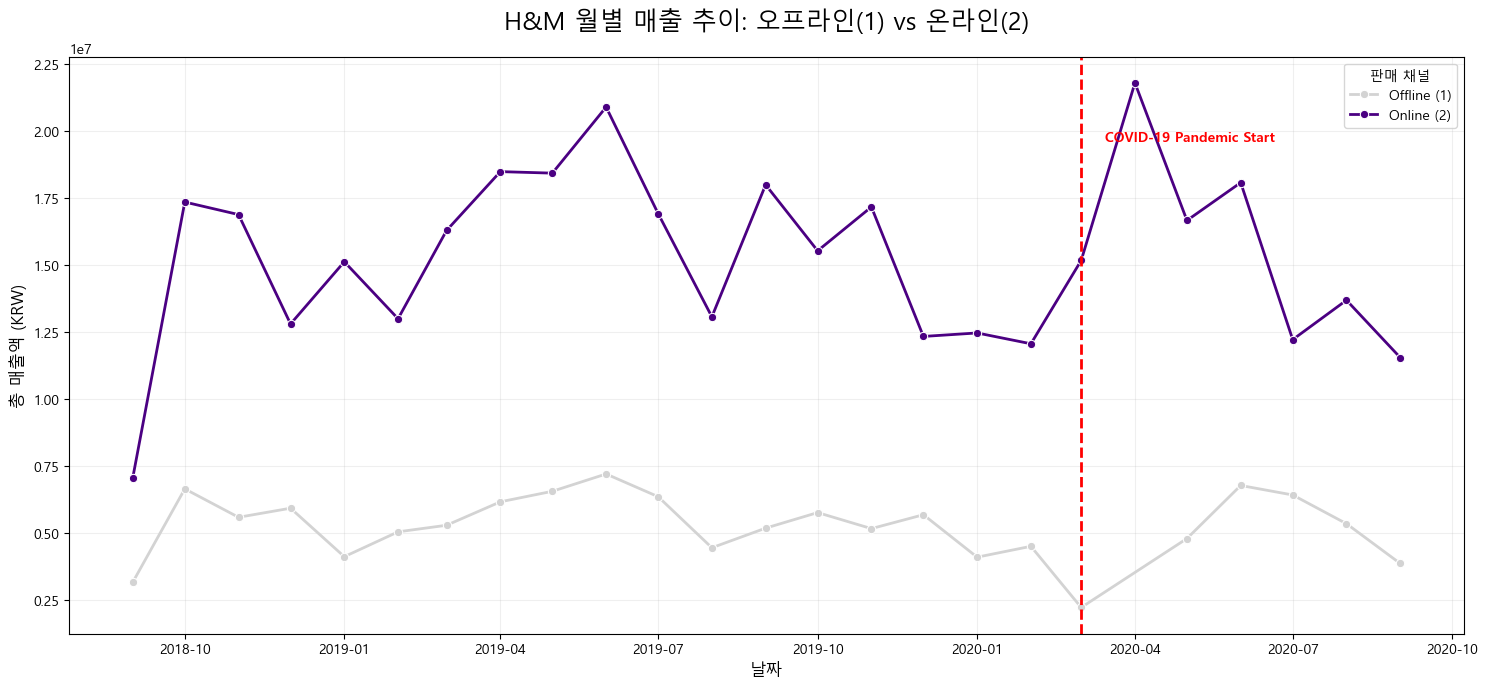

In [8]:
# 2. 월별 집계
df['month_year'] = df['t_dat'].dt.to_period('M')

# 3. 채널별 매출 및 고객수 집계
monthly_analysis = df.groupby(['month_year', 'sales_channel_id']).agg({
    'price': 'sum',
    'customer_id': 'nunique'
}).reset_index()

# 시각화를 위해 다시 datetime으로 변환
monthly_analysis['month_year'] = monthly_analysis['month_year'].dt.to_timestamp()

# --- 수정 포인트 시작 ---
# 4. 시각화 (색상 매핑을 명확히 지정)
plt.figure(figsize=(15, 7))

# 색상 딕셔너리 생성 (1: 오프라인, 2: 온라인)
# 오프라인은 흐린 색, 온라인은 강조되는 진한 색으로 설정하여 대조를 줍니다.
palette_colors = {1: "#D3D3D3", 2: "#4B0082"} 

# lineplot 실행 시 palette 파라미터를 사용하면 hue 값에 색상이 고정됩니다.
sns.lineplot(
    data=monthly_analysis, 
    x='month_year', 
    y='price', 
    hue='sales_channel_id', 
    palette=palette_colors, 
    marker='o',
    linewidth=2
)

# 5. 팬데믹 시작 시점 표시
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=2)
plt.text(pd.Timestamp('2020-03-15'), monthly_analysis['price'].max() * 0.9, 
         'COVID-19 Pandemic Start', color='red', fontweight='bold')

# 6. 범례 및 라벨 정리 (수동 labels 대신 딕셔너리 매핑 권장)
# 자동으로 생성된 범례의 텍스트만 깔끔하게 바꿔줍니다.
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Offline (1)', 'Online (2)'], title='판매 채널', loc='upper right')

plt.title('H&M 월별 매출 추이: 오프라인(1) vs 온라인(2)', size=18, pad=20)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('총 매출액 (KRW)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [9]:
# 온라인의 폭발적 성장 (Online 2): 온라인 매출은 팬데믹 직후 역대 최고치를 찍으며 급상승

# 오프라인의 침체 (Offline 1): 팬데믹 선포 직후 매출이 급격히 하락하여 역대 최저 수준을 기록

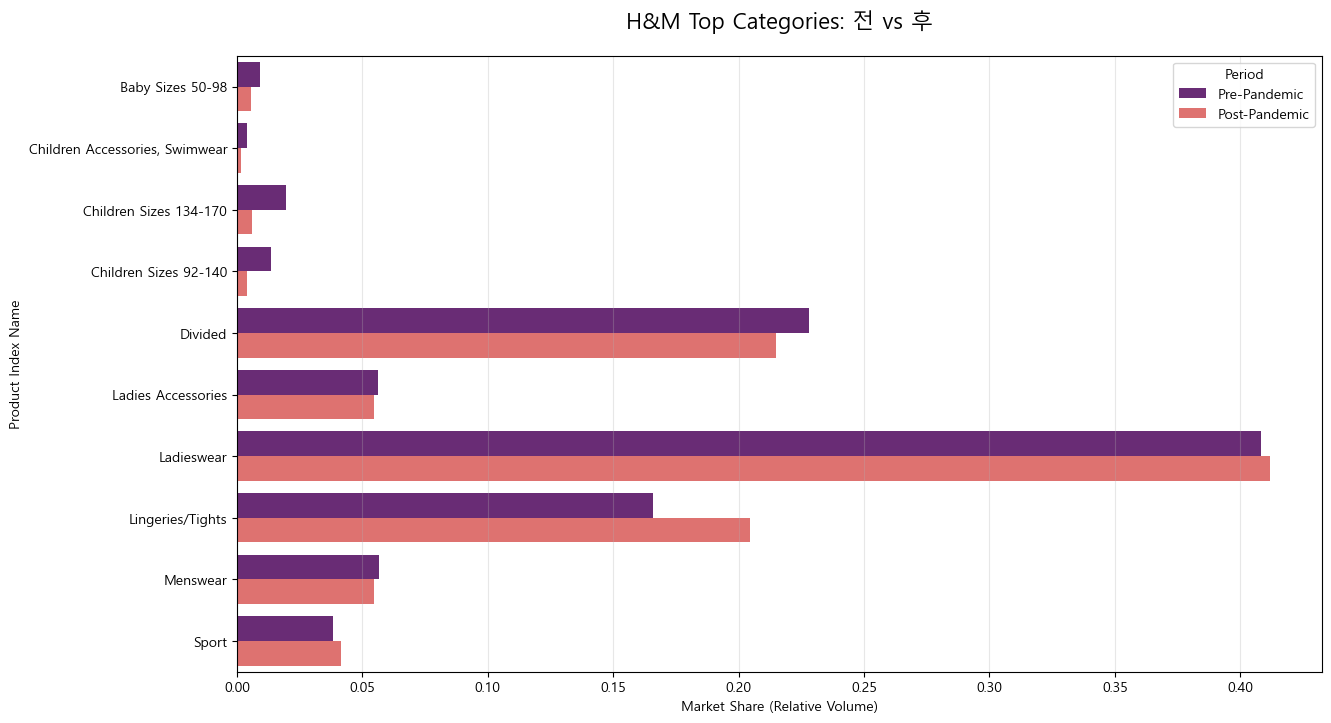

In [10]:
# 2. 기간 분리 (2020년 3월 기준)
# 2020년 3월 이후를 'Post-Pandemic'으로 설정하여 비즈니스 시의성을 보완합니다
pre_covid = df[df['t_dat'] < '2020-03-01']
post_covid = df[df['t_dat'] >= '2020-03-01']

# 3. 기간별 인기 상품군 집계 (판매량 기준)
pre_rank = pre_covid['index_name'].value_counts(normalize=True).head(10).reset_index()
pre_rank.columns = ['Category', 'Share']
pre_rank['Period'] = 'Pre-Pandemic'

post_rank = post_covid['index_name'].value_counts(normalize=True).head(10).reset_index()
post_rank.columns = ['Category', 'Share']
post_rank['Period'] = 'Post-Pandemic'

# 데이터 합치기
comparison_df = pd.concat([pre_rank, post_rank])

# 4. 시각화 (도표 비교)
plt.figure(figsize=(14, 8))
sns.barplot(data=comparison_df, y='Category', x='Share', hue='Period', palette='magma')

plt.title('H&M Top Categories: 전 vs 후', size=16, pad=20)
plt.xlabel('Market Share (Relative Volume)')
plt.ylabel('Product Index Name')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [11]:
# Lingeries/Tights의 급증: 팬데믹 이후 점유율이 가장 눈에 띄게 상승 재택근무와 실내 거주 시간이 늘어나며 실용적이고 편안한 의류에 대한 수요 증가한 것으로 보임

# Ladieswear의 견고함: 여전히 가장 큰 비중을 차지하며 핵심 상품군으로서의 위치를 지키고 있음

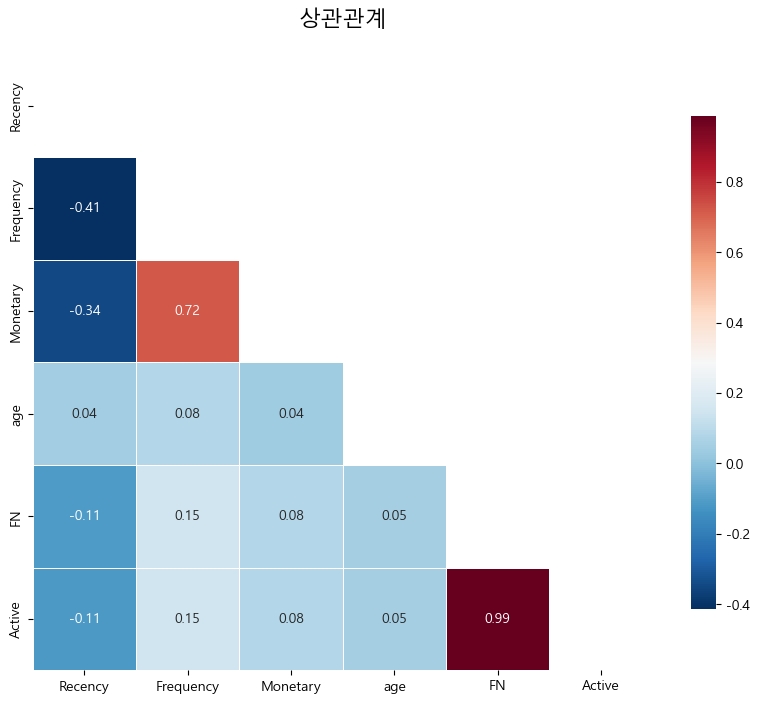

In [12]:
# 1. 상관관계 분석을 위한 핵심 컬럼 선정
# Recency, Frequency, Monetary: 현재 고객 가치
# age: 인구통계학적 특성
# FN, Active: 마케팅 활동성
corr_cols = ['Recency', 'Frequency', 'Monetary', 'age', 'FN', 'Active']

# 2. 상관계수 행렬 계산 (결측치는 제외하고 계산됨)
corr_matrix = ltv_df[corr_cols].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 상삼각형 가리기 (중복 제거)

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리까지
            cmap='RdBu_r',       # 붉은색(양), 푸른색(음) 컬러맵
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('상관관계', size=16, pad=20)
plt.show()

In [13]:
# Frequency & Monetary (0.72): 구매 빈도와 총 구매액 사이에 강한 양(+)의 상관관계가 있음. 즉, 자주 오는 고객이 결국 매출 기여도가 가장 높다는 정석적인 결과.

# Recency & Frequency (-0.41): 최근 구매일이 오래될수록(Recency 증가) 구매 빈도가 낮아지는 음(-)의 상관관계가 뚜렷. 고객이 잊기 전에 리마인드하는 것이 얼마나 중요한지 보여줌.

# FN & Active (0.99): 마케팅 수신 동의(FN)와 활성 상태(Active)는 거의 동일하게 움직임.

# 추가 인사이트: Age와 다른 지표 간의 상관관계(0.04~0.08)가 낮게 나타나는 점으로 보아, 특정 연령대보다는 구매 패턴(RFM) 자체를 기준으로 타겟팅하는 것이 더 정교한 접근임을 시사

In [14]:
# 1. CSV 파일로 저장
# encoding='utf-8-sig'는 엑셀에서 열었을 때 한글(페르소나 명)이 깨지는 것을 방지합니다.
# index=False는 불필요한 인덱스 번호가 컬럼으로 추가되는 것을 막아줍니다.
# df.to_csv('final_hm_cluster.csv', index=False, encoding='utf-8-sig')

# print("✅ 메인 거래 데이터(df) CSV 저장 완료!")

## 근거 확실하게 찾기

In [15]:
# 1. Cluster 2 고객들만 필터링
c2_ids = rfm[rfm['Cluster'] == 2]['customer_id']
c2_df = df[df['customer_id'].isin(c2_ids)].copy()

# 2. 고객별로 날짜마다 몇 개를 샀는지 계산 (장바구니 크기)
c2_basket = c2_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')

# 3. 각 고객별로 주문 순서 매기기 (가장 최근 주문이 1)
c2_basket['order_rank'] = c2_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 4. 마지막 1회차부터 5회차까지 필터링
c2_last_5 = c2_basket[c2_basket['order_rank'] <= 5].copy()

# 5. 순서별로 평균 구매 수량 계산
# 1.0은 마지막 주문, 5.0은 이탈 5회 전 주문입니다.
last_5_trend = c2_last_5.groupby('order_rank')['basket_size'].mean()

print("📉 Cluster 2의 이탈 전 마지막 5회 주문당 평균 구매 수량:")
print(last_5_trend)

📉 Cluster 2의 이탈 전 마지막 5회 주문당 평균 구매 수량:
order_rank
1.0    3.450283
2.0    3.617848
3.0    3.498901
4.0    3.358744
5.0    3.264200
Name: basket_size, dtype: float64


In [16]:
# 1. Cluster 2 고객들만 필터링
c2_ids = rfm[rfm['Cluster'] == 2]['customer_id']
c2_df = df[df['customer_id'].isin(c2_ids)].copy()

# 2. 주문(고객+날짜)별로 상품 종류(product_type_name)가 몇 개인지 계산
# 예: 한 날짜에 상의 2개, 하의 1개를 샀다면 종류는 '2개'로 카운트됩니다.
c2_diversity = c2_df.groupby(['customer_id', 't_dat'])['product_type_name'].nunique().reset_index(name='type_diversity')

# 3. 각 고객별로 주문 순서 매기기 (1.0이 가장 최근/마지막 주문)
c2_diversity['order_rank'] = c2_diversity.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 4. 마지막 1회차부터 5회차까지의 평균 카테고리 종류 수 계산
last_5_diversity = c2_diversity[c2_diversity['order_rank'] <= 5].groupby('order_rank')['type_diversity'].mean()

print("📉 Cluster 2의 이탈 전 마지막 5회 주문당 평균 카테고리 종류 수:")
print(last_5_diversity)

📉 Cluster 2의 이탈 전 마지막 5회 주문당 평균 카테고리 종류 수:
order_rank
1.0    2.114007
2.0    2.200934
3.0    2.174058
4.0    2.138383
5.0    2.114155
Name: type_diversity, dtype: float64


In [17]:
# 1. 상의/하의 여부 플래그 생성 (H&M 데이터의 product_group_name 활용)
c2_df['is_upper'] = c2_df['product_group_name'].str.contains('Upper', case=False)
c2_df['is_lower'] = c2_df['product_group_name'].str.contains('Lower', case=False)

# 2. 주문별로 상의/하의 포함 여부 요약
order_set_check = c2_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

# 3. 상의와 하의를 모두 산 '세트 구매' 여부 판단
order_set_check['is_set_purchase'] = order_set_check['is_upper'] & order_set_check['is_lower']

# 4. 아까 만든 order_rank(주문 순서)와 병합
# (이전에 만든 c2_basket의 order_rank를 활용)
order_set_check = order_set_check.merge(
    c2_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

# 5. 시점별 세트 구매율 계산
set_purchase_trend = order_set_check.groupby('order_rank')['is_set_purchase'].mean()

print("🎯 Cluster 2의 이탈 전 마지막 5회 '상의+하의' 세트 구매율 추이:")
print(set_purchase_trend)

🎯 Cluster 2의 이탈 전 마지막 5회 '상의+하의' 세트 구매율 추이:
order_rank
1.0     0.219241
2.0     0.235124
3.0     0.228526
4.0     0.223962
5.0     0.221056
6.0     0.216723
7.0     0.216999
8.0     0.202395
9.0     0.208347
10.0    0.210689
11.0    0.194397
12.0    0.188732
13.0    0.175355
14.0    0.203252
15.0    0.141791
16.0    0.157143
17.0    0.148936
18.0    0.166667
19.0    0.250000
20.0    0.571429
21.0    0.250000
22.0    0.500000
23.0    0.000000
Name: is_set_purchase, dtype: float64


In [18]:
from statsmodels.stats.proportion import proportions_ztest

# 1. 각 시점별 데이터 개수(n)와 세트 구매 성공 횟수(count) 추출
# order_rank 2.0 (정점)
n_2 = len(order_set_check[order_set_check['order_rank'] == 2.0])
count_2 = order_set_check[order_set_check['order_rank'] == 2.0]['is_set_purchase'].sum()

# order_rank 1.0 (마지막)
n_1 = len(order_set_check[order_set_check['order_rank'] == 1.0])
count_1 = order_set_check[order_set_check['order_rank'] == 1.0]['is_set_purchase'].sum()

# 2. Z-검정 실시 (비율이 하락했는지 확인하는 one-sided test)
z_stat, p_val = proportions_ztest([count_1, count_2], [n_1, n_2], alternative='smaller')

print(f"📊 정점 대비 마지막 주문의 세트 구매율 비교:")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ 결과: 통계적으로 유의미한 하락입니다. (이탈 신호 확정)")
else:
    print("❓ 결과: 통계적으로 유의미하지 않습니다. (단순 오차 가능성)")

📊 정점 대비 마지막 주문의 세트 구매율 비교:
P-value: 0.0000
✅ 결과: 통계적으로 유의미한 하락입니다. (이탈 신호 확정)


In [19]:
# 1. Cluster 0 고객들만 필터링
c0_ids = rfm[rfm['Cluster'] == 0]['customer_id']
c0_df = df[df['customer_id'].isin(c0_ids)].copy()

# 2. 장바구니 크기 및 주문 순서(Order Rank) 계산
c0_basket = c0_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')
c0_basket['order_rank'] = c0_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 3. 상의/하의 세트 구매 여부 확인
c0_df['is_upper'] = c0_df['product_group_name'].str.contains('Upper', case=False)
c0_df['is_lower'] = c0_df['product_group_name'].str.contains('Lower', case=False)

c0_set_check = c0_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

c0_set_check['is_set_purchase'] = c0_set_check['is_upper'] & c0_set_check['is_lower']

# 4. 주문 순서 병합 및 트렌드 확인
c0_set_check = c0_set_check.merge(
    c0_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

c0_trend = c0_set_check[c0_set_check['order_rank'] <= 10].groupby('order_rank')['is_set_purchase'].mean()

print("🚨 Cluster 0(위험군)의 최근 10회 주문당 세트 구매율 추이:")
print(c0_trend)

🚨 Cluster 0(위험군)의 최근 10회 주문당 세트 구매율 추이:
order_rank
1.0     0.195412
2.0     0.207834
3.0     0.209928
4.0     0.210875
5.0     0.208623
6.0     0.203688
7.0     0.197459
8.0     0.189519
9.0     0.183387
10.0    0.169350
Name: is_set_purchase, dtype: float64


In [20]:
# 1. Cluster 3 고객들만 필터링
c3_ids = rfm[rfm['Cluster'] == 3]['customer_id']
c3_df = df[df['customer_id'].isin(c3_ids)].copy()

# 2. 장바구니 크기 및 주문 순서(Order Rank) 계산
c3_basket = c3_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')
c3_basket['order_rank'] = c3_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 3. 상의/하의 세트 구매 여부 확인
c3_df['is_upper'] = c3_df['product_group_name'].str.contains('Upper', case=False)
c3_df['is_lower'] = c3_df['product_group_name'].str.contains('Lower', case=False)

c3_set_check = c3_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

c3_set_check['is_set_purchase'] = c3_set_check['is_upper'] & c0_set_check['is_lower']

# 4. 주문 순서 병합 및 트렌드 확인 (최근 10회 기준)
c3_set_check = c3_set_check.merge(
    c3_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

c3_trend = c3_set_check[c3_set_check['order_rank'] <= 10].groupby('order_rank')['is_set_purchase'].mean()

print("📈 Cluster 3의 최근 10회 주문당 세트 구매율 추이:")
print(c3_trend)

📈 Cluster 3의 최근 10회 주문당 세트 구매율 추이:
order_rank
1.0     0.240999
2.0     0.229597
3.0     0.224193
4.0     0.213484
5.0     0.214324
6.0     0.221306
7.0     0.218579
8.0     0.226349
9.0     0.225263
10.0    0.231322
Name: is_set_purchase, dtype: float64


In [21]:
# 1. Cluster 1 고객들만 필터링
c1_ids = rfm[rfm['Cluster'] == 1]['customer_id']
c1_df = df[df['customer_id'].isin(c1_ids)].copy()

# 2. 장바구니 크기 및 주문 순서(Order Rank) 계산
c1_basket = c1_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')
c1_basket['order_rank'] = c1_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 3. 상의/하의 세트 구매 여부 확인
c1_df['is_upper'] = c1_df['product_group_name'].str.contains('Upper', case=False)
c1_df['is_lower'] = c1_df['product_group_name'].str.contains('Lower', case=False)

c1_set_check = c1_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

c1_set_check['is_set_purchase'] = c1_set_check['is_upper'] & c1_set_check['is_lower']

# 4. 주문 순서 병합 및 트렌드 확인 (최근 10회 기준)
c1_set_check = c1_set_check.merge(
    c1_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

c1_trend = c1_set_check[c1_set_check['order_rank'] <= 10].groupby('order_rank')['is_set_purchase'].mean()

print("💎 Cluster 1(우수 고객)의 최근 10회 주문당 세트 구매율 추이:")
print(c1_trend)

💎 Cluster 1(우수 고객)의 최근 10회 주문당 세트 구매율 추이:
order_rank
1.0     0.233393
2.0     0.243300
3.0     0.247710
4.0     0.248801
5.0     0.247383
6.0     0.248042
7.0     0.247909
8.0     0.245841
9.0     0.245916
10.0    0.240363
Name: is_set_purchase, dtype: float64


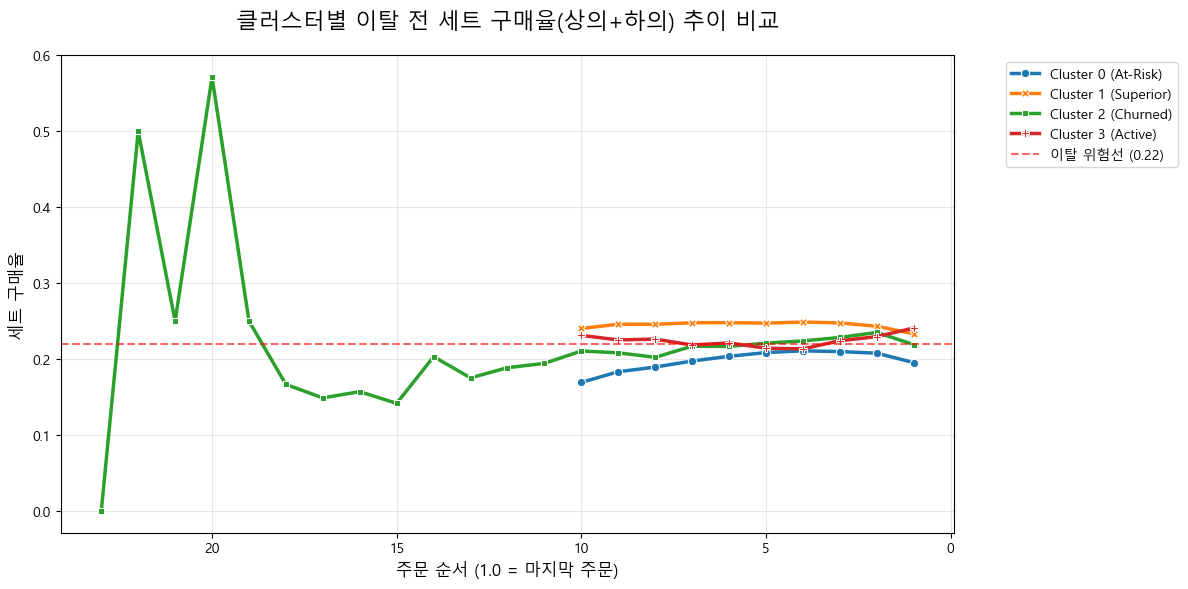

In [28]:
# 1. 데이터 합치기 (이미 계산된 각 클러스터의 trend 시리즈 활용)
# 주의: 앞에서 계산한 c0_trend, c1_trend, c2_trend, c3_trend를 사용합니다.
comparison_df = pd.DataFrame({
    'Cluster 0 (At-Risk)': c0_trend,
    'Cluster 1 (Superior)': c1_trend,
    'Cluster 2 (Churned)': set_purchase_trend, # 아까 만든 C2 데이터
    'Cluster 3 (Active)': c3_trend
})

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
sns.lineplot(data=comparison_df, markers=True, dashes=False, linewidth=2.5)

# 3. 그래프 꾸미기
plt.title('클러스터별 이탈 전 세트 구매율(상의+하의) 추이 비교', fontsize=16, pad=20)
plt.xlabel('주문 순서 (1.0 = 마지막 주문)', fontsize=12)
plt.ylabel('세트 구매율', fontsize=12)
plt.gca().invert_xaxis() # 1.0이 오른쪽 끝에 오도록 순서 뒤집기
plt.axhline(y=0.22, color='red', linestyle='--', alpha=0.6, label='이탈 위험선 (0.22)') # 위험선 표시
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

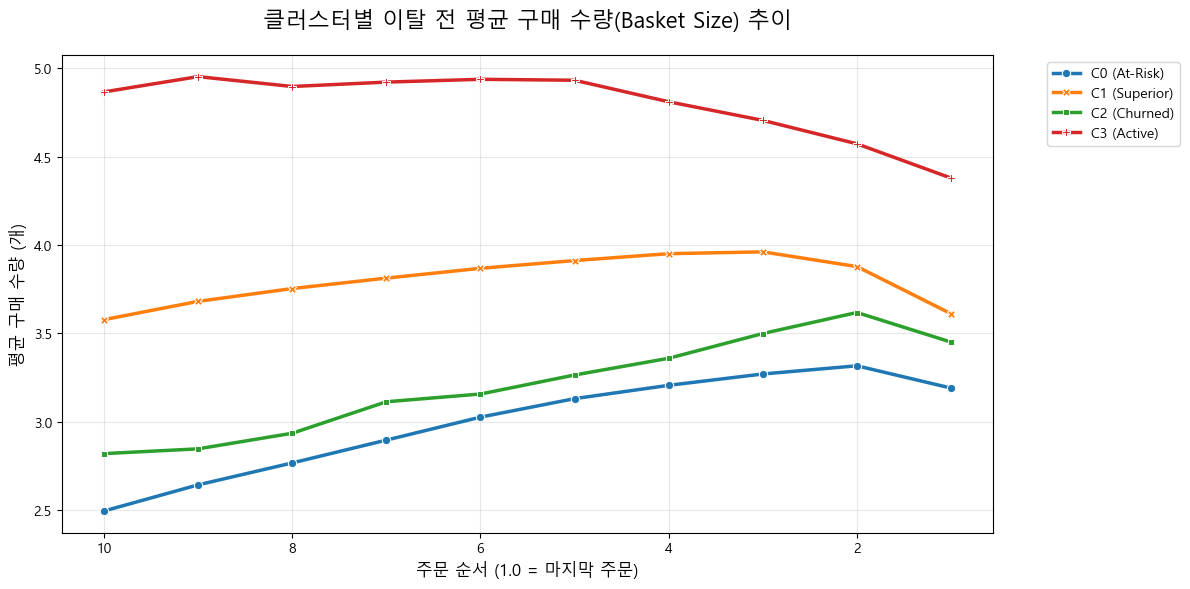

In [24]:
# 1. 각 클러스터별 평균 basket_size 트렌드 계산
# (이미 앞에서 생성한 c0_basket, c1_basket, c2_basket, c3_basket 활용)

size_comparison = pd.DataFrame({
    'C0 (At-Risk)': c0_basket[c0_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean(),
    'C1 (Superior)': c1_basket[c1_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean(),
    'C2 (Churned)': c2_basket[c2_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean(),
    'C3 (Active)': c3_basket[c3_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean()
})

# 2. 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=size_comparison, markers=True, dashes=False, linewidth=2.5)

plt.title('클러스터별 이탈 전 평균 구매 수량(Basket Size) 추이', fontsize=16, pad=20)
plt.xlabel('주문 순서 (1.0 = 마지막 주문)', fontsize=12)
plt.ylabel('평균 구매 수량 (개)', fontsize=12)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

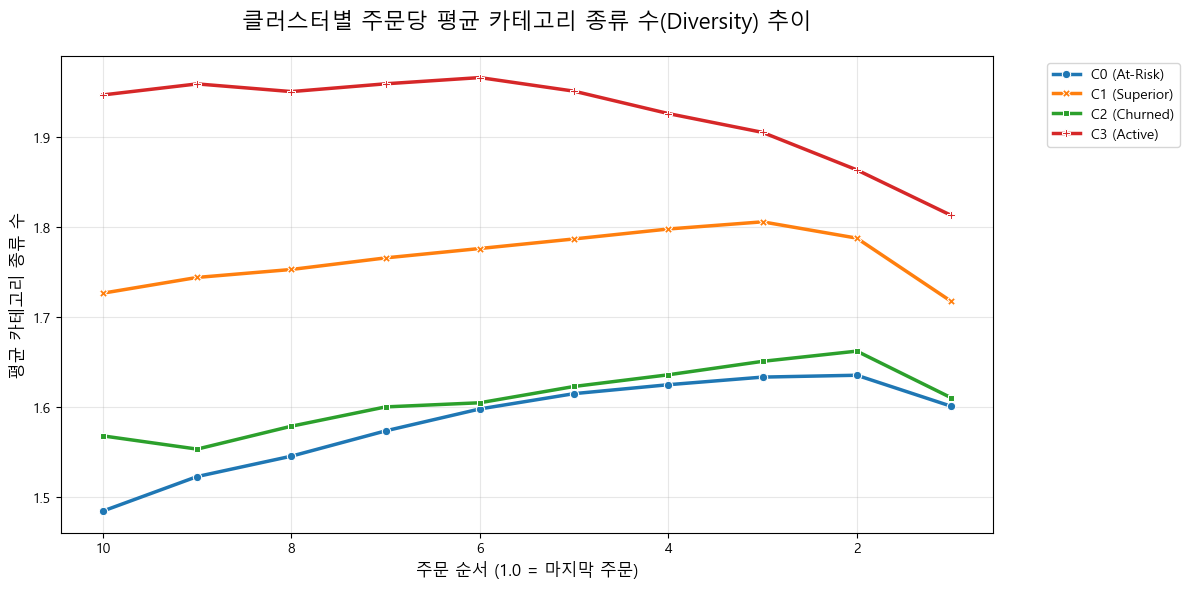

In [29]:
# 1. 각 클러스터별 카테고리 종류 수(Diversity) 계산 함수
def get_diversity_trend(df_cluster, basket_summary):
    # 주문별 유니크한 카테고리 개수 계산
    diversity = df_cluster.groupby(['customer_id', 't_dat'])['product_group_name'].nunique().reset_index(name='category_count')
    
    # 주문 순서(order_rank) 병합
    diversity = diversity.merge(basket_summary[['customer_id', 't_dat', 'order_rank']], on=['customer_id', 't_dat'])
    
    # 순서별 평균 계산
    return diversity.groupby('order_rank')['category_count'].mean()

# 2. 각 클러스터별 트렌드 산출
# (기존에 생성한 c0_basket, c1_basket, c2_basket, c3_basket 활용)
c0_div = get_diversity_trend(c0_df, c0_basket)
c1_div = get_diversity_trend(c1_df, c1_basket)
c2_div = get_diversity_trend(c2_df, c2_basket)
c3_div = get_diversity_trend(c3_df, c3_basket)

# 3. 데이터 합치기
div_comparison = pd.DataFrame({
    'C0 (At-Risk)': c0_div,
    'C1 (Superior)': c1_div,
    'C2 (Churned)': c2_div,
    'C3 (Active)': c3_div
})

# 4. 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=div_comparison[div_comparison.index <= 10], markers=True, dashes=False, linewidth=2.5)

plt.title('클러스터별 주문당 평균 카테고리 종류 수(Diversity) 추이', fontsize=16, pad=20)
plt.xlabel('주문 순서 (1.0 = 마지막 주문)', fontsize=12)
plt.ylabel('평균 카테고리 종류 수', fontsize=12)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

💰 클러스터별 총 매출 기여도:
   Cluster  Total_Monetary
1        1     214723712.0
0        0     142318896.0
3        3     112586944.0
2        2      39835888.0


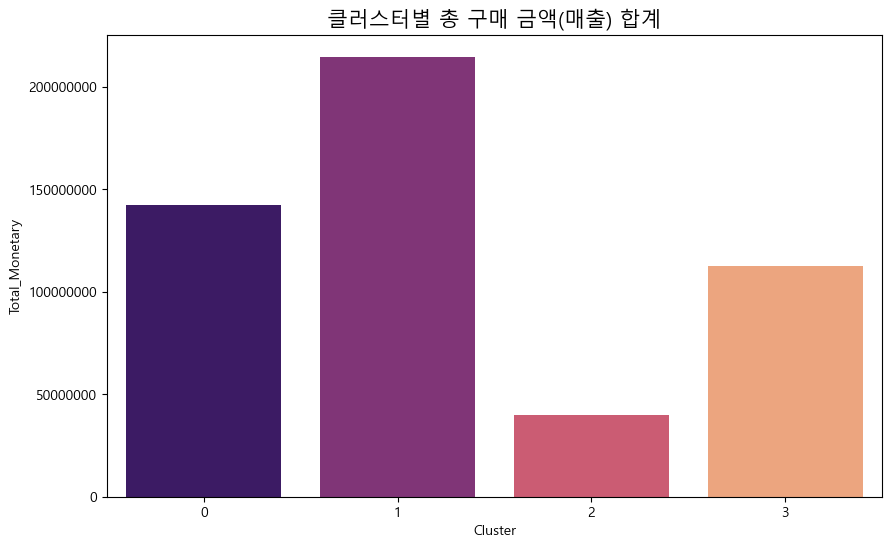

In [31]:
# 1. rfm 데이터프레임의 컬럼명 확인 및 처리
# 만약 컬럼명이 'Monetary'처럼 대문자로 시작한다면 아래 코드가 자동으로 잡아줍니다.
target_col = [col for col in rfm.columns if col.lower() == 'monetary']

if not target_col:
    # 만약 rfm에 금액 데이터가 없다면, 원본 df에서 직접 합산하여 연결
    print("⚠️ rfm에 금액 컬럼이 없어 원본 데이터에서 직접 계산합니다.")
    monetary_df = df.groupby('customer_id')['price'].sum().reset_index(name='monetary')
    rfm = rfm.merge(monetary_df, on='customer_id', how='left')
    target_col = ['monetary']

# 2. 클러스터별 총 구매 금액 합계 계산
cluster_monetary = rfm.groupby('Cluster')[target_col[0]].sum().reset_index()
cluster_monetary.columns = ['Cluster', 'Total_Monetary']

# 3. 결과 출력 (내림차순 정렬)
cluster_monetary = cluster_monetary.sort_values(by='Total_Monetary', ascending=False)
print("💰 클러스터별 총 매출 기여도:")
print(cluster_monetary)

# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster', y='Total_Monetary', data=cluster_monetary, palette='magma')
plt.title('클러스터별 총 구매 금액(매출) 합계', fontsize=15)
plt.ticklabel_format(style='plain', axis='y') # 지수 표현 방지
plt.show()

📉 Cluster 2의 마지막 쇼핑 리스트 (비중 높은 순):
             Category     Share
0  Garment Upper body  0.412755
1  Garment Lower body  0.222537
2   Garment Full body  0.094345
3            Swimwear  0.085798
4           Underwear  0.072744
5         Accessories  0.047599
6      Socks & Tights  0.026223
7               Shoes  0.023785
8           Nightwear  0.012513
9             Unknown  0.001203


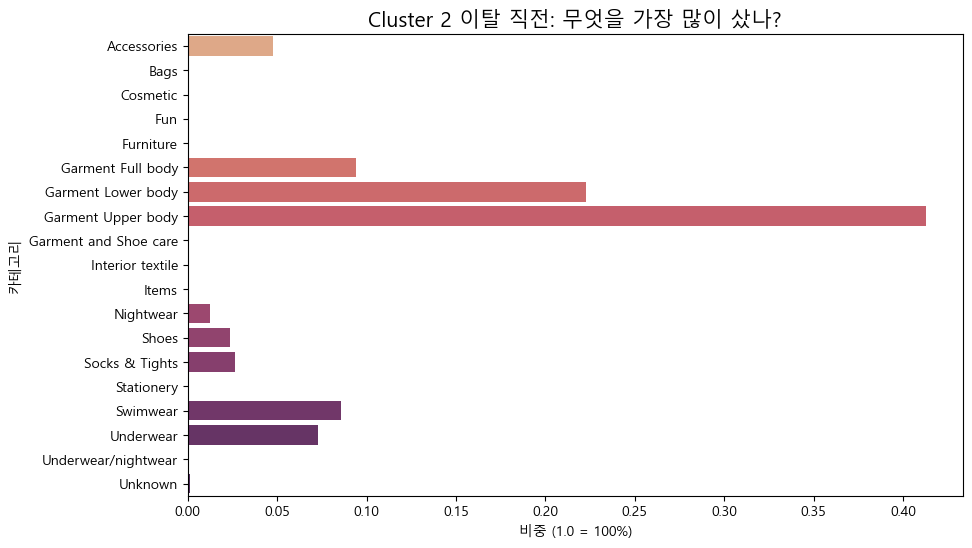

In [34]:
# [1단계] 데이터 준비: Cluster 2의 마지막 주문 아이템만 가져오기
c2_mask = (rfm['Cluster'] == 2)
c2_ids = rfm[c2_mask]['customer_id']

# 마지막 주문(order_rank 1.0) 데이터만 필터링
last_order_filter = (order_set_check['customer_id'].isin(c2_ids)) & (order_set_check['order_rank'] == 1.0)
last_orders = order_set_check[last_order_filter]

# 상세 상품 정보 합치기
final_items = df.merge(last_orders[['customer_id', 't_dat']], on=['customer_id', 't_dat'])

# [2단계] 비중 계산 및 정렬
# value_counts()를 쓰면 자동으로 큰 순서대로 정렬됩니다!
category_rank = final_items['product_group_name'].value_counts(normalize=True).reset_index()
category_rank.columns = ['Category', 'Share']

print("📉 Cluster 2의 마지막 쇼핑 리스트 (비중 높은 순):")
print(category_rank.head(10))

# [3단계] 시각화 (깔끔한 정렬 버전)
plt.figure(figsize=(10, 6))
# 굳이 따로 정렬 코드를 안 넣어도 category_rank 자체가 이미 정렬되어 있습니다.
sns.barplot(data=category_rank.head(10), x='Share', y='Category', palette='flare')

plt.title('Cluster 2 이탈 직전: 무엇을 가장 많이 샀나?', fontsize=15)
plt.xlabel('비중 (1.0 = 100%)')
plt.ylabel('카테고리')
plt.show()

In [40]:
df

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name,month_year
0,2018-09-20,2,663713001,2999.00%,2,0,0,ACTIVE,NONE,24,...,Solid,Black,Dark,Black,Expressive Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear",2018-09
1,2018-09-20,2,541518023,1799.00%,2,0,0,ACTIVE,NONE,24,...,Solid,Light Pink,Dusty Light,Pink,Casual Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear",2018-09
2,2018-09-20,7,505221004,899.00%,2,1,1,ACTIVE,Regularly,32,...,Melange,Pink,Medium Dusty,Pink,Tops Knitwear DS,Divided,Divided,Divided Selected,Knitwear,2018-09
3,2018-09-20,7,685687003,999.00%,2,1,1,ACTIVE,Regularly,32,...,Melange,Pink,Medium,Pink,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers,2018-09
4,2018-09-20,7,685687004,999.00%,2,1,1,ACTIVE,Regularly,32,...,Melange,Dark Green,Dark,Green,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers,2018-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31097418,2020-09-22,1361247,918522001,2499.00%,2,1,1,ACTIVE,Regularly,30,...,Solid,Off White,Light,White,Knitwear,Ladieswear,Ladieswear,Womens Everyday Collection,Knitwear,2020-09
31097419,2020-09-22,1361247,918485001,3999.00%,2,1,1,ACTIVE,Regularly,30,...,Solid,Light Beige,Dusty Light,Beige,Blouse & Dress,Ladieswear,Ladieswear,Womens Trend,Blouses,2020-09
31097420,2020-09-22,1362025,918325001,2549.00%,1,0,0,ACTIVE,NONE,67,...,Application/3D,Black,Dark,Black,Bags,Ladies Accessories,Ladieswear,Womens Big accessories,Accessories,2020-09
31097421,2020-09-22,1362050,833459002,399.00%,1,1,1,ACTIVE,Regularly,21,...,Solid,Silver,Light,Metal,Jewellery,Ladies Accessories,Ladieswear,Womens Small accessories,Accessories,2020-09
